# Raw CSV Feature Audit: Events and Usage

This notebook performs a complete feature-level analysis of:
- `data/raw/sample_instance_events.csv`
- `data/raw/sample_instance_usage.csv`

It covers:
1. Dataset shape and preview
2. Column-by-column schema and missingness
3. Full distinct values for each feature (saved to files)
4. Frequency tables for low-cardinality features
5. Numeric distribution summaries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)

RAW_DIR = Path('../data/raw')
OUT_DIR = Path('../data/processed/feature_audit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'events': RAW_DIR / 'sample_instance_events_forced.csv',
    'usage': RAW_DIR / 'sample_instance_usage_forced.csv',
}

dfs = {name: pd.read_csv(path) for name, path in DATASETS.items()}

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}, file={DATASETS[name]}")
    display(df.head(5))

events: shape=(844844, 6), file=../data/raw/sample_instance_events_forced.csv


,collection_id,priority,scheduling_class,resource_request_cpus,resource_request_ram,machine_id
0,385223982662,0,0,0.003345,0.001711,NaN
1,380762246352,107,1,0.024750,0.002476,NaN
2,395296320970,0,1,0.008362,0.001221,NaN
3,378253165591,0,0,0.004753,0.005501,NaN
4,383069141836,107,1,0.002026,0.001774,NaN


usage: shape=(45860944, 5), file=../data/raw/sample_instance_usage_forced.csv


,collection_id,start_time,end_time,average_usage_cpus,average_usage_memory
0,385223982662,206700000000,207000000000,0.000168,3.597260e-03
1,380762246352,78416000000,78417000000,0.000000,0.000000e+00
2,395296320970,686953000000,686954000000,0.000000,9.536743e-07
3,378253165591,821267000000,821270000000,0.000147,1.335144e-04
4,383069141836,680382000000,680400000000,0.000918,6.093979e-04


In [2]:
def feature_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        non_null = int(s.notna().sum())
        nulls = int(s.isna().sum())
        nunique = int(s.nunique(dropna=True))
        rows.append(
            {
                'column': col,
                'dtype': str(s.dtype),
                'rows': n,
                'non_null': non_null,
                'nulls': nulls,
                'null_pct': (nulls / n) * 100 if n else np.nan,
                'unique_non_null_values': nunique,
                'is_numeric': pd.api.types.is_numeric_dtype(s),
            }
        )
    return pd.DataFrame(rows).sort_values(['is_numeric', 'unique_non_null_values', 'column'], ascending=[False, False, True]).reset_index(drop=True)

profiles = {name: feature_profile(df) for name, df in dfs.items()}

for name, profile in profiles.items():
    print(f"\n=== {name.upper()} FEATURE PROFILE ===")
    display(profile)


=== EVENTS FEATURE PROFILE ===


,column,dtype,rows,non_null,nulls,null_pct,unique_non_null_values,is_numeric
0,machine_id,float64,844844,19511,825333,97.690580,7563,True
1,resource_request_ram,float64,844844,844649,195,0.023081,3796,True
2,collection_id,int64,844844,844844,0,0.000000,2000,True
3,resource_request_cpus,float64,844844,844649,195,0.023081,1748,True
4,priority,int64,844844,844844,0,0.000000,11,True
5,scheduling_class,int64,844844,844844,0,0.000000,4,True



=== USAGE FEATURE PROFILE ===


,column,dtype,rows,non_null,nulls,null_pct,unique_non_null_values,is_numeric
0,start_time,int64,45860944,45860944,0,0.0,1084025,True
1,end_time,int64,45860944,45860944,0,0.0,1046816,True
2,average_usage_cpus,float64,45860944,45860944,0,0.0,5446,True
3,average_usage_memory,float64,45860944,45860944,0,0.0,3844,True
4,collection_id,int64,45860944,45860944,0,0.0,1977,True


In [3]:
def distinct_values_table(series: pd.Series) -> pd.DataFrame:
    vc = series.value_counts(dropna=False)
    out = vc.reset_index()
    out.columns = ['value', 'count']
    out['pct'] = (out['count'] / len(series)) * 100
    # Normalize value to string for robust CSV export and easier visual inspection.
    out['value_repr'] = out['value'].map(lambda x: '<NA>' if pd.isna(x) else str(x))
    return out[['value', 'value_repr', 'count', 'pct']]

all_distinct_tables = {}

for ds_name, df in dfs.items():
    ds_dir = OUT_DIR / ds_name
    ds_dir.mkdir(parents=True, exist_ok=True)
    all_distinct_tables[ds_name] = {}

    for col in df.columns:
        table = distinct_values_table(df[col])
        all_distinct_tables[ds_name][col] = table

        out_path = ds_dir / f"{col}__distinct_values.csv"
        table.to_csv(out_path, index=False)

    print(f"Saved full distinct-value tables for {ds_name} in: {ds_dir}")

Saved full distinct-value tables for events in: ../data/processed/feature_audit/events
Saved full distinct-value tables for usage in: ../data/processed/feature_audit/usage


In [4]:
# Display complete value frequencies for low-cardinality columns.
LOW_CARDINALITY_THRESHOLD = 60

for ds_name, df in dfs.items():
    print(f"\n=== {ds_name.upper()} LOW-CARDINALITY FEATURES (<= {LOW_CARDINALITY_THRESHOLD} unique values) ===")
    profile = profiles[ds_name]
    low_card_cols = profile.loc[profile['unique_non_null_values'] <= LOW_CARDINALITY_THRESHOLD, 'column'].tolist()

    if not low_card_cols:
        print('No low-cardinality columns found.')
        continue

    for col in low_card_cols:
        print(f"\n--- {col} ---")
        display(all_distinct_tables[ds_name][col])


=== EVENTS LOW-CARDINALITY FEATURES (<= 60 unique values) ===

--- priority ---


,value,value_repr,count,pct
0,0,0,519229,61.458565
1,103,103,169105,20.016121
2,105,105,108845,12.883444
3,200,200,18571,2.198157
4,107,107,14124,1.671788
5,119,119,5739,0.679297
6,116,116,5343,0.632424
7,115,115,2342,0.277211
8,118,118,976,0.115524
9,25,25,437,0.051726



--- scheduling_class ---


,value,value_repr,count,pct
0,0,0,562042,66.526128
1,1,1,275945,32.662243
2,2,2,5974,0.707113
3,3,3,883,0.104516



=== USAGE LOW-CARDINALITY FEATURES (<= 60 unique values) ===
No low-cardinality columns found.


In [5]:
# Numeric summary for all numeric features (distribution-friendly stats).
for ds_name, df in dfs.items():
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n=== {ds_name.upper()} NUMERIC SUMMARY ===")
    if not num_cols:
        print('No numeric columns found.')
        continue

    summary = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    summary['nulls'] = df[num_cols].isna().sum()
    summary['null_pct'] = (summary['nulls'] / len(df)) * 100
    display(summary)

# Optional: inspect one high-cardinality column at a time with full frequency table.
# Example:
# display(all_distinct_tables['usage']['start_time'])


=== EVENTS NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,844844.0,3.842329e+11,1.654364e+10,2.012986e+10,3.609373e+11,3.786186e+11,3.809975e+11,3.831220e+11,3.855600e+11,3.994829e+11,4.001957e+11,4.004647e+11,0,0.000000
priority,844844.0,4.239604e+01,5.542492e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.030000e+02,1.070000e+02,2.000000e+02,3.600000e+02,0,0.000000
scheduling_class,844844.0,3.439002e-01,4.960306e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,0,0.000000
resource_request_cpus,844649.0,9.351984e-03,1.317889e-02,0.000000e+00,7.047653e-04,2.025604e-03,3.433228e-03,7.041931e-03,1.004028e-02,2.474976e-02,4.052734e-02,5.810547e-01,195,0.023081
resource_request_ram,844649.0,5.775980e-03,8.362185e-03,0.000000e+00,6.361008e-04,1.302719e-03,2.021790e-03,3.906250e-03,6.507874e-03,1.821899e-02,2.865601e-02,3.061523e-01,195,0.023081
machine_id,19511.0,7.335864e+10,1.006705e+11,2.073177e+07,2.073692e+07,2.124399e+07,1.580069e+09,3.587326e+10,9.216150e+10,3.607140e+11,3.764706e+11,3.989597e+11,825333,97.690580



=== USAGE NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,45860944.0,3.940005e+11,7.809681e+09,2.012986e+10,3.773259e+11,3.806440e+11,3.935574e+11,3.975324e+11,3.980420e+11,3.980521e+11,4.003095e+11,4.004647e+11,0,0.0
start_time,45860944.0,9.334562e+11,7.929377e+11,3.000000e+08,1.320000e+10,6.450000e+10,3.087000e+11,6.114000e+11,1.464900e+12,2.444700e+12,2.620500e+12,2.678998e+12,0,0.0
end_time,45860944.0,9.337256e+11,7.929140e+11,6.000000e+08,1.350000e+10,6.480000e+10,3.087060e+11,6.117000e+11,1.465200e+12,2.444744e+12,2.620800e+12,2.679000e+12,0,0.0
average_usage_cpus,45860944.0,6.767349e-03,2.219355e-02,0.000000e+00,0.000000e+00,1.077652e-04,2.756119e-04,5.273819e-04,5.996704e-03,2.020264e-02,1.350098e-01,1.449219e+00,0,0.0
average_usage_memory,45860944.0,3.497673e-03,2.954961e-03,0.000000e+00,9.536743e-07,1.525879e-04,4.205704e-04,3.791809e-03,5.485535e-03,8.148193e-03,1.289368e-02,8.276367e-02,0,0.0


## Static Batch EDA: Workload, Mechanism, and Costs

This section analyzes `data/processed/static_batch_may2019.csv` to validate:
1. Heavy-tailed workload physics and overprovisioning
2. Valuation/virtual-value behavior from mechanism design
3. Energy and cost relationships before dynamic grid integration

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

PROCESSED_PATH = Path('../data/processed/static_batch_may2019.csv')
processed_df = pd.read_csv(PROCESSED_PATH)

print(f"Loaded processed dataset: {PROCESSED_PATH}")
print(f"Shape: {processed_df.shape}")
display(processed_df.head(5))

duration_col = 'D' if 'D' in processed_df.columns else 'D (hours)'
if duration_col not in processed_df.columns:
    raise ValueError("Expected a duration column named 'D' or 'D (hours)'.")

required_cols = [
    'A_cpu', 'A_ram', duration_col, 'actual_cpu_usage',
    'v', 'phi_v', 'w_j_kw', 'C_elec', 'C_carbon'
 ]
missing_cols = [c for c in required_cols if c not in processed_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in processed dataset: {missing_cols}")
print(f"Using duration column: {duration_col}")

Loaded processed dataset: ../data/processed/static_batch_may2019.csv
Shape: (1977, 14)


,collection_id,job_datetime,A_cpu,A_ram,actual_cpu_usage,actual_ram_usage,D (hours),v,phi_v,w_j_kw,elec_price_per_kWh,carbon_intensity_gCO2_per_kWh,C_elec,C_carbon
0,383044398050,2019-05-01 00:05:00,4.267406,3.071987,0.001084,0.006884,744.083333,1196.241801,846.428018,0.020466,0.031366,330.784619,0.477660,251.868362
1,384666769426,2019-05-01 00:05:00,0.008453,0.006508,0.000106,0.000007,744.083333,1.681407,0.936785,0.000041,0.031366,330.784619,0.000952,0.501790
2,396353658785,2019-05-01 00:05:00,0.010746,0.003819,0.000238,0.003544,744.083333,0.427098,-5.555512,0.000049,0.031366,330.784619,0.001153,0.607730
3,381581703409,2019-05-01 00:05:00,11.200719,8.019781,0.000091,0.000449,744.083333,1822.563018,800.446152,0.053694,0.031366,330.784619,1.253164,660.789285
4,400258011113,2019-05-01 00:05:00,1.375648,1.788795,0.000549,0.000438,744.083333,271.512665,93.449582,0.007037,0.031366,330.784619,0.164229,86.597502


Using duration column: D (hours)


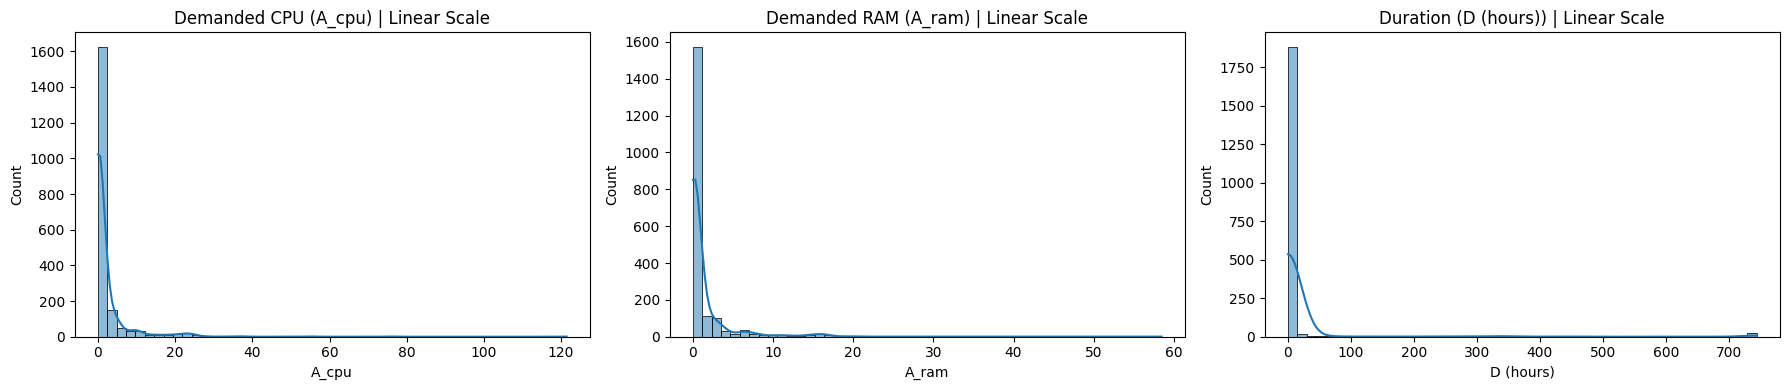

/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


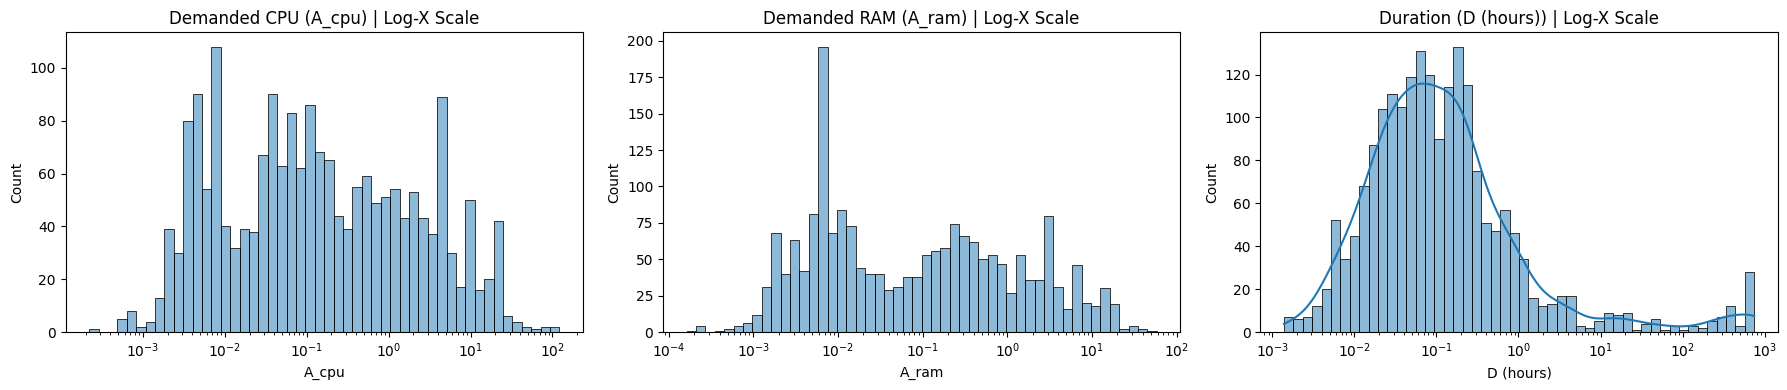

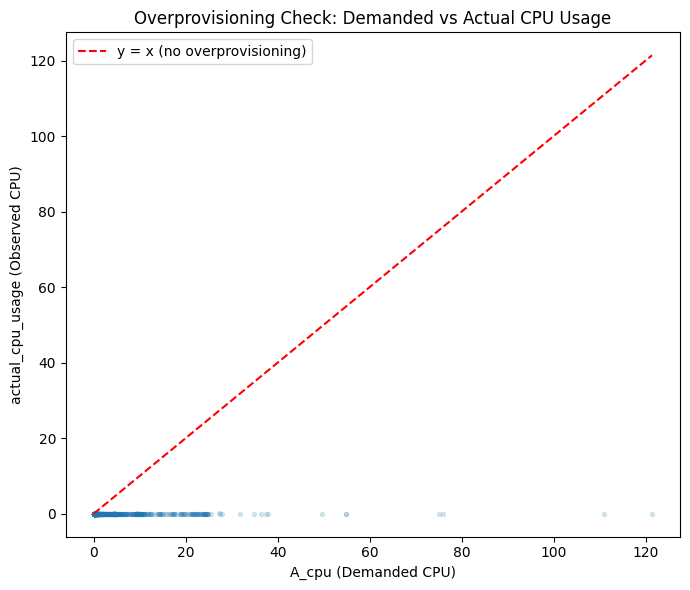

Share of jobs with actual_cpu_usage < A_cpu: 89.48%


In [7]:
# 1) Workload Physics: heavy tails + overprovisioning
feature_cols = ['A_cpu', 'A_ram', duration_col]
feature_titles = [
    'Demanded CPU (A_cpu)',
    'Demanded RAM (A_ram)',
    f'Duration ({duration_col})',
]

# Linear-scale histograms (direct magnitude comparison).
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, feature_cols, feature_titles):
    sns.histplot(processed_df[col].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(f'{title} | Linear Scale')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Log-scale histograms (tail/shape visibility across orders of magnitude).
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, feature_cols, feature_titles):
    sns.histplot(processed_df[col].dropna(), kde=True, log_scale=True, ax=ax, bins=50)
    ax.set_title(f'{title} | Log-X Scale')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
scatter_df = processed_df[['A_cpu', 'actual_cpu_usage']].dropna()
sns.scatterplot(
    data=scatter_df.sample(n=min(15000, len(scatter_df)), random_state=42),
    x='A_cpu',
    y='actual_cpu_usage',
    alpha=0.2,
    s=12,
    edgecolor=None,
 )

max_axis = float(np.nanmax([scatter_df['A_cpu'].max(), scatter_df['actual_cpu_usage'].max()]))
plt.plot([0, max_axis], [0, max_axis], linestyle='--', color='red', label='y = x (no overprovisioning)')
plt.title('Overprovisioning Check: Demanded vs Actual CPU Usage')
plt.xlabel('A_cpu (Demanded CPU)')
plt.ylabel('actual_cpu_usage (Observed CPU)')
plt.legend()
plt.tight_layout()
plt.show()

overprov_ratio = (
    (scatter_df['actual_cpu_usage'] < scatter_df['A_cpu']).mean()
    if len(scatter_df) else np.nan
 )
print(f"Share of jobs with actual_cpu_usage < A_cpu: {overprov_ratio:.2%}")

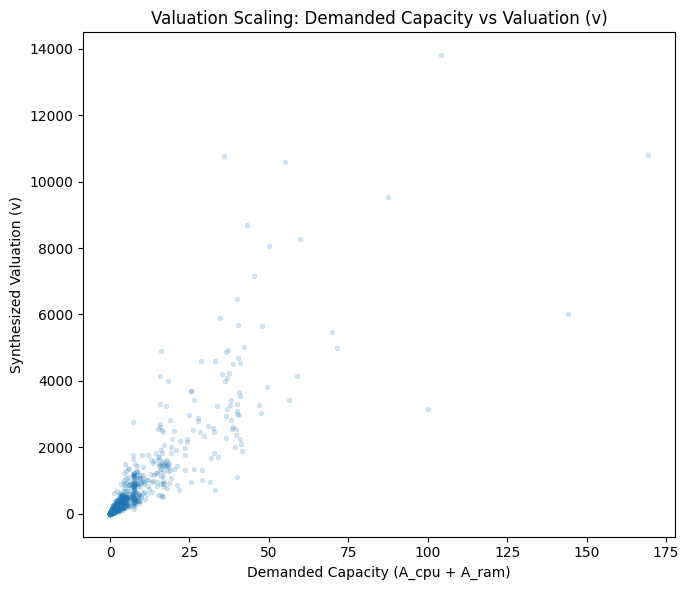

Pearson corr(demanded_capacity, v): 0.876


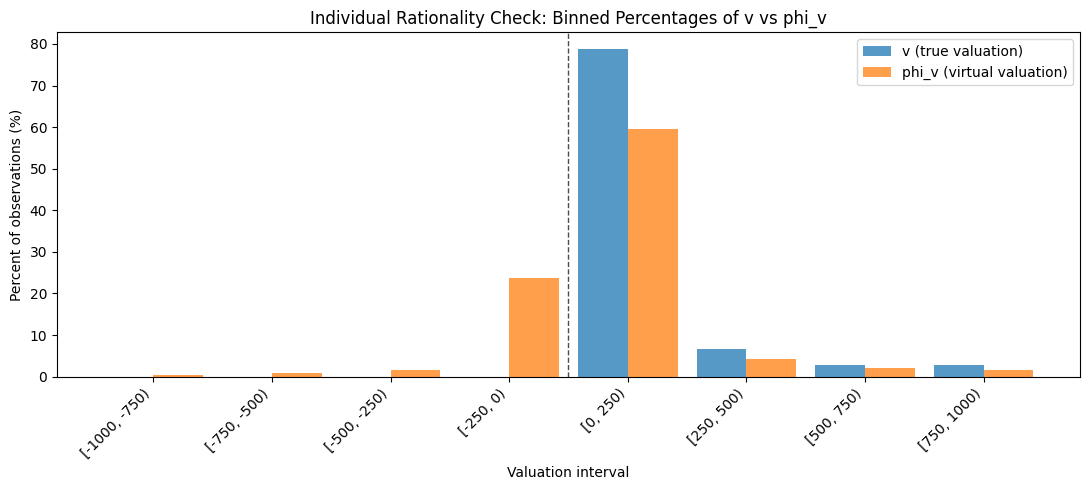

Optimal Auction Rejection Rate: 28.78%


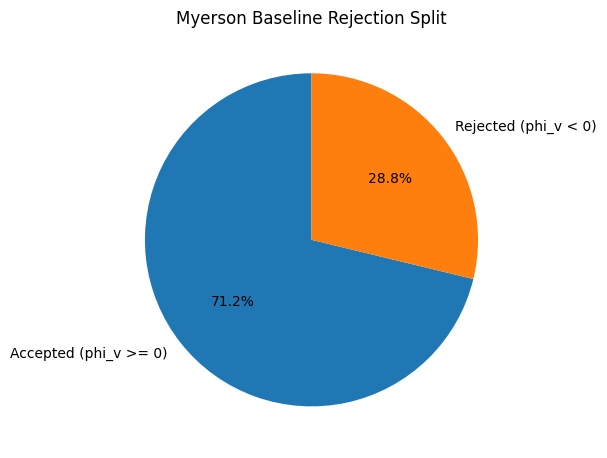

In [15]:
# 2) Economic Mechanism Design: valuations and virtual values
econ_df = processed_df[['A_cpu', 'A_ram', 'v', 'phi_v']].dropna().copy()
econ_df['demanded_capacity'] = econ_df['A_cpu'] + econ_df['A_ram']

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=econ_df.sample(n=min(15000, len(econ_df)), random_state=42),
    x='demanded_capacity',
    y='v',
    alpha=0.2,
    s=12,
    edgecolor=None,
 )
plt.title('Valuation Scaling: Demanded Capacity vs Valuation (v)')
plt.xlabel('Demanded Capacity (A_cpu + A_ram)')
plt.ylabel('Synthesized Valuation (v)')
plt.tight_layout()
plt.show()

corr_val = econ_df[['demanded_capacity', 'v']].corr().iloc[0, 1]
print(f"Pearson corr(demanded_capacity, v): {corr_val:.3f}")

# Build one shared binned table that is reused by both plot and table output.
interval_step = 250
zoom_min, zoom_max = -1000, 1000
inner_edges = list(range(zoom_min, zoom_max + interval_step, interval_step))
bin_edges = [-np.inf] + inner_edges + [np.inf]

def build_interval_labels(edges):
    labels = [f'< {edges[1]}']
    for left, right in zip(edges[1:-2], edges[2:-1]):
        labels.append(f'[{left}, {right})')
    labels.append(f'>= {edges[-2]}')
    return labels

interval_labels = build_interval_labels(bin_edges)

def interval_table(series: pd.Series, col_name: str) -> pd.DataFrame:
    binned = pd.cut(series, bins=bin_edges, right=False, labels=interval_labels, include_lowest=True)
    counts = binned.value_counts(sort=False).rename(f'{col_name}_count')
    pcts = (counts / counts.sum() * 100).rename(f'{col_name}_pct')
    return pd.concat([counts, pcts], axis=1)

v_intervals = interval_table(econ_df['v'], 'v')
phi_intervals = interval_table(econ_df['phi_v'], 'phi_v')
interval_occurrence_table = pd.concat([v_intervals, phi_intervals], axis=1).reset_index()
interval_occurrence_table = interval_occurrence_table.rename(columns={'index': 'valuation_interval'})

# Plot exactly the same binned percentages shown in the table (zoomed to [-1000, 1000]).
zoom_labels = [f'[{left}, {left + interval_step})' for left in range(zoom_min, zoom_max, interval_step)]
zoom_table = interval_occurrence_table[interval_occurrence_table['valuation_interval'].isin(zoom_labels)].copy()
zoom_table['left_edge'] = zoom_table['valuation_interval'].str.extract(r'\[(-?\d+),')[0].astype(int)
zoom_table = zoom_table.sort_values('left_edge')

x = np.arange(len(zoom_table))
width = 0.42
plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, zoom_table['v_pct'], width=width, label='v (true valuation)', alpha=0.75)
plt.bar(x + width / 2, zoom_table['phi_v_pct'], width=width, label='phi_v (virtual valuation)', alpha=0.75)
plt.xticks(x, zoom_table['valuation_interval'], rotation=45, ha='right')
plt.title('Individual Rationality Check: Binned Percentages of v vs phi_v')
plt.xlabel('Valuation interval')
plt.ylabel('Percent of observations (%)')
plt.axvline((0 - zoom_min) / interval_step - 0.5, linestyle='--', color='black', linewidth=1, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

rejected = int((econ_df['phi_v'] < 0).sum())
accepted = int((econ_df['phi_v'] >= 0).sum())
rejection_rate = rejected / len(econ_df) if len(econ_df) else np.nan
print(f"Optimal Auction Rejection Rate: {rejection_rate:.2%}")

plt.figure(figsize=(6, 6))
plt.pie(
    [accepted, rejected],
    labels=['Accepted (phi_v >= 0)', 'Rejected (phi_v < 0)'],
    autopct='%1.1f%%',
    startangle=90,
 )
plt.title('Myerson Baseline Rejection Split')
plt.tight_layout()
plt.show()

In [ ]:
# Interval frequency table for actual valuations (v) and virtual valuations (phi_v).
# Reuse the same binned output computed in Cell 10 to keep plot/table perfectly aligned.
if 'interval_occurrence_table' not in globals():
    interval_step = 250
    zoom_min, zoom_max = -1000, 1000
    inner_edges = list(range(zoom_min, zoom_max + interval_step, interval_step))
    bin_edges = [-np.inf] + inner_edges + [np.inf]

    def build_interval_labels(edges):
        labels = [f'< {edges[1]}']
        for left, right in zip(edges[1:-2], edges[2:-1]):
            labels.append(f'[{left}, {right})')
        labels.append(f'>= {edges[-2]}')
        return labels

    interval_labels = build_interval_labels(bin_edges)

    def interval_table(series: pd.Series, col_name: str) -> pd.DataFrame:
        binned = pd.cut(series, bins=bin_edges, right=False, labels=interval_labels, include_lowest=True)
        counts = binned.value_counts(sort=False).rename(f'{col_name}_count')
        pcts = (counts / counts.sum() * 100).rename(f'{col_name}_pct')
        return pd.concat([counts, pcts], axis=1)

    econ_df = processed_df[['v', 'phi_v']].dropna().copy()
    v_intervals = interval_table(econ_df['v'], 'v')
    phi_intervals = interval_table(econ_df['phi_v'], 'phi_v')
    interval_occurrence_table = pd.concat([v_intervals, phi_intervals], axis=1).reset_index()
    interval_occurrence_table = interval_occurrence_table.rename(columns={'index': 'valuation_interval'})

display(interval_occurrence_table)

,valuation_interval,v_count,v_pct,phi_v_count,phi_v_pct
0,< -1000,0,0.000000,40,2.023268
1,"[-1000, -750)",0,0.000000,9,0.455235
2,"[-750, -500)",0,0.000000,16,0.809307
3,"[-500, -250)",0,0.000000,33,1.669196
4,"[-250, 0)",0,0.000000,471,23.823976
5,"[0, 250)",1559,78.856854,1179,59.635812
6,"[250, 500)",131,6.626201,86,4.350025
7,"[500, 750)",57,2.883156,42,2.124431
8,"[750, 1000)",54,2.731411,33,1.669196
9,>= 1000,176,8.902377,68,3.439555


/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


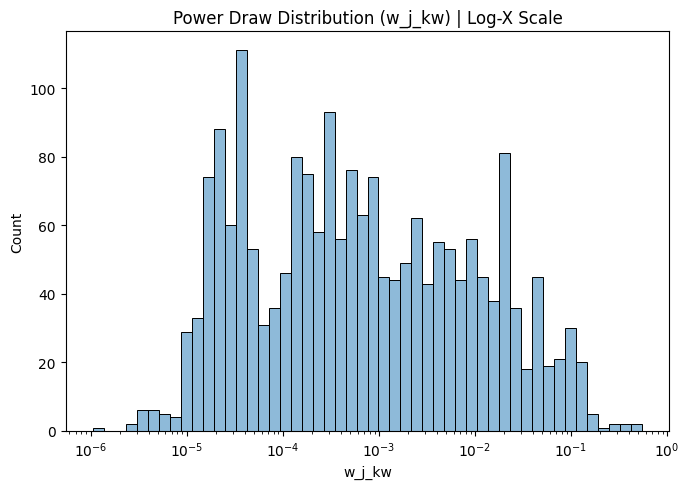

Top 5 jobs by w_j_kw:


,collection_id,A_cpu,A_ram,D (hours),w_j_kw,C_elec,C_carbon
625,377795153893,121.429860,22.678816,0.129722,0.546765,0.002198,1.165115
640,20129862094,110.981445,58.475098,0.144722,0.520480,0.001528,1.022182
1420,360937258671,75.949051,28.076309,0.001944,0.349618,0.000014,0.009305
467,397117467315,75.009096,12.601035,0.048611,0.336971,0.000364,0.230862
356,375078090986,54.914597,45.041492,0.002222,0.266397,0.000029,0.012469


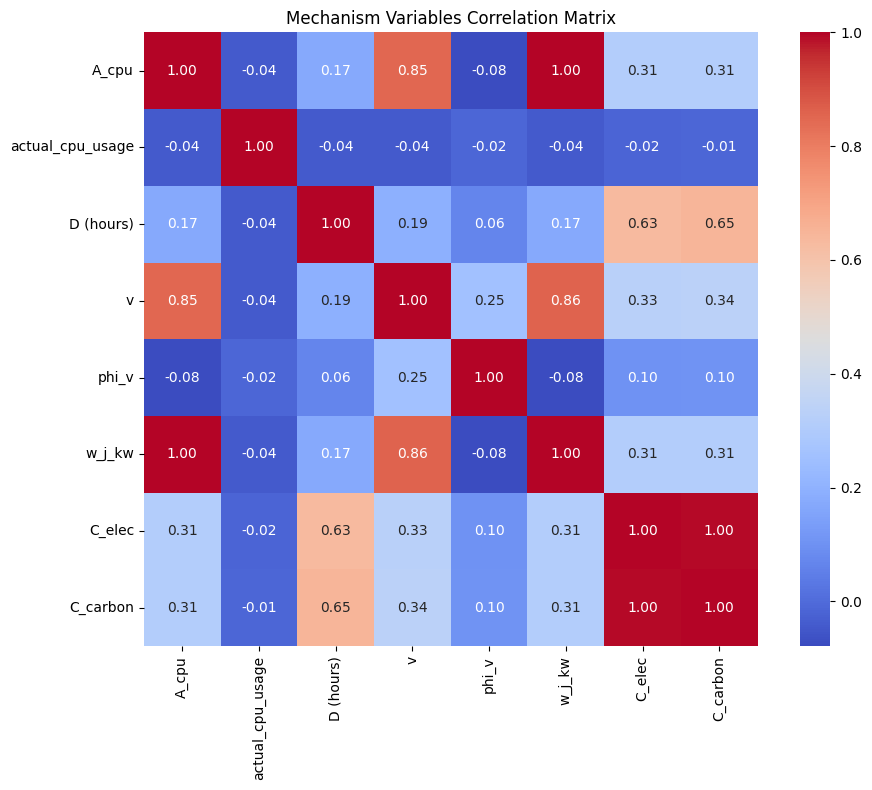

Optimal Auction Rejection Rate (full dataset): 28.78%
corr(C_elec, w_j_kw * duration): 0.9794
corr(C_carbon, w_j_kw * duration): 0.9944
corr(C_elec, C_carbon): 0.9953


In [9]:
# 3) Objective Costs: power profiling + correlation diagnostics
plt.figure(figsize=(7, 5))
sns.histplot(processed_df['w_j_kw'].dropna(), kde=True, log_scale=True, bins=50)
plt.title('Power Draw Distribution (w_j_kw) | Log-X Scale')
plt.xlabel('w_j_kw')
plt.tight_layout()
plt.show()

print('Top 5 jobs by w_j_kw:')
display(processed_df.nlargest(5, 'w_j_kw')[['collection_id', 'A_cpu', 'A_ram', duration_col, 'w_j_kw', 'C_elec', 'C_carbon']])

# Correlation Matrix (starter anomaly check)
cols = ['A_cpu', 'actual_cpu_usage', duration_col, 'v', 'phi_v', 'w_j_kw', 'C_elec', 'C_carbon']
corr = processed_df[cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Mechanism Variables Correlation Matrix')
plt.tight_layout()
plt.show()

# Rejection rate recap using the full processed dataset.
rejected_full = int((processed_df['phi_v'] < 0).sum())
print(f"Optimal Auction Rejection Rate (full dataset): {rejected_full / len(processed_df):.2%}")

# Static-grid consistency check: both costs should move together strongly.
proxy = processed_df['w_j_kw'] * processed_df[duration_col]
print(f"corr(C_elec, w_j_kw * duration): {processed_df['C_elec'].corr(proxy):.4f}")
print(f"corr(C_carbon, w_j_kw * duration): {processed_df['C_carbon'].corr(proxy):.4f}")
print(f"corr(C_elec, C_carbon): {processed_df['C_elec'].corr(processed_df['C_carbon']):.4f}")